## **Kelompok 13 I-3 ML Prak**

### 1. Import Package

In [23]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.cluster import KMeans 
from sklearn.metrics import silhouette_score

### 2. Import Data

In [24]:
df = pd.read_excel('data_customer.xlsx') 
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-01-12 08:26:00,255,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-01-12 08:26:00,339,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-01-12 08:26:00,275,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-01-12 08:26:00,339,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-01-12 08:26:00,339,17850.0,United Kingdom


### 3. Amati Bentuk Data

In [25]:
df.shape

(541909, 8)

### 4. Melihat ringkasan statistik deskriptif dari DataFrame

In [26]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,232959,5.419090e+05,406829.000000
mean,9.552250,2011-05-14 03:14:20.515884800,4.084587e+02,15287.690570
min,-80995.000000,2010-01-12 08:26:00,-1.106206e+06,12346.000000
25%,1.000000,2011-03-04 11:36:00,8.500000e+01,13953.000000
50%,3.000000,2011-06-09 10:46:00,1.950000e+02,15152.000000
75%,10.000000,2011-09-06 10:46:00,3.950000e+02,16791.000000
max,80995.000000,2011-12-10 17:19:00,1.783646e+06,18287.000000
std,218.081158,NaN,7.770606e+03,1713.600303


### 5. Cek null data

In [27]:
#Mengecek jika ada data yang null
print("Pengecekan Missing Value".center(75, "="))
print(df.isnull().sum())
print("=" * 75)

==========================Pengecekan Missing Value=========================
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate    308950
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


### 6. Penanganan Missing Value

In [28]:
# Menghapus baris yang mengandung nilai null
df.dropna(inplace=True)

# Menghapus baris dengan nilai null di kolom 'Description', 'InvoiceDate', dan 'CustomerID'
df_cleaned = df.dropna(subset=['Description', 'InvoiceDate', 'CustomerID'])

# Mengecek kembali jumlah nilai null setelah dibersihkan
print("Data setelah menghapus missing value".center(75, "="))
print(df.isnull().sum())
print("=" * 75)
df_cleaned.isnull().sum()

====================Data setelah menghapus missing value===================
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

### 7. Cek Outlier

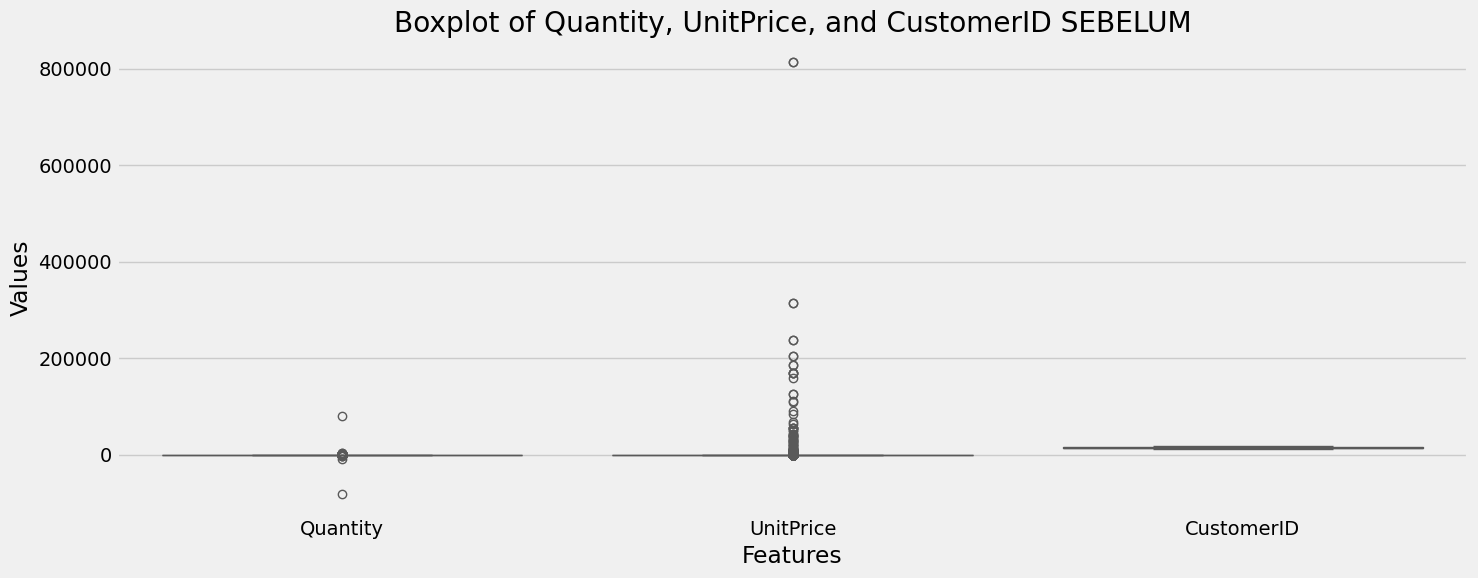

In [29]:
plt.figure(figsize=(15, 6))
sns.boxplot(data=df_cleaned[['Quantity', 'UnitPrice', 'CustomerID']], palette="Set2")
plt.title('Boxplot of Quantity, UnitPrice, and CustomerID SEBELUM')
plt.xlabel('Features')
plt.ylabel('Values')
plt.tight_layout()
plt.show()

In [30]:
# Fungsi untuk mengganti outlier dengan mean
def replace_outliers_with_mean(column):
    # Menghitung IQR
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    
    # Mendefinisikan batas atas dan bawah
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Hitung mean kolom tanpa outlier
    mean_value = column[(column >= lower_bound) & (column <= upper_bound)].mean()
    
    # Ganti outlier dengan mean
    column = np.where((column < lower_bound) | (column > upper_bound), mean_value, column)
    return column

df_cleaned['Quantity'] = replace_outliers_with_mean(df_cleaned['Quantity'])
df_cleaned['UnitPrice'] = replace_outliers_with_mean(df_cleaned['UnitPrice'])

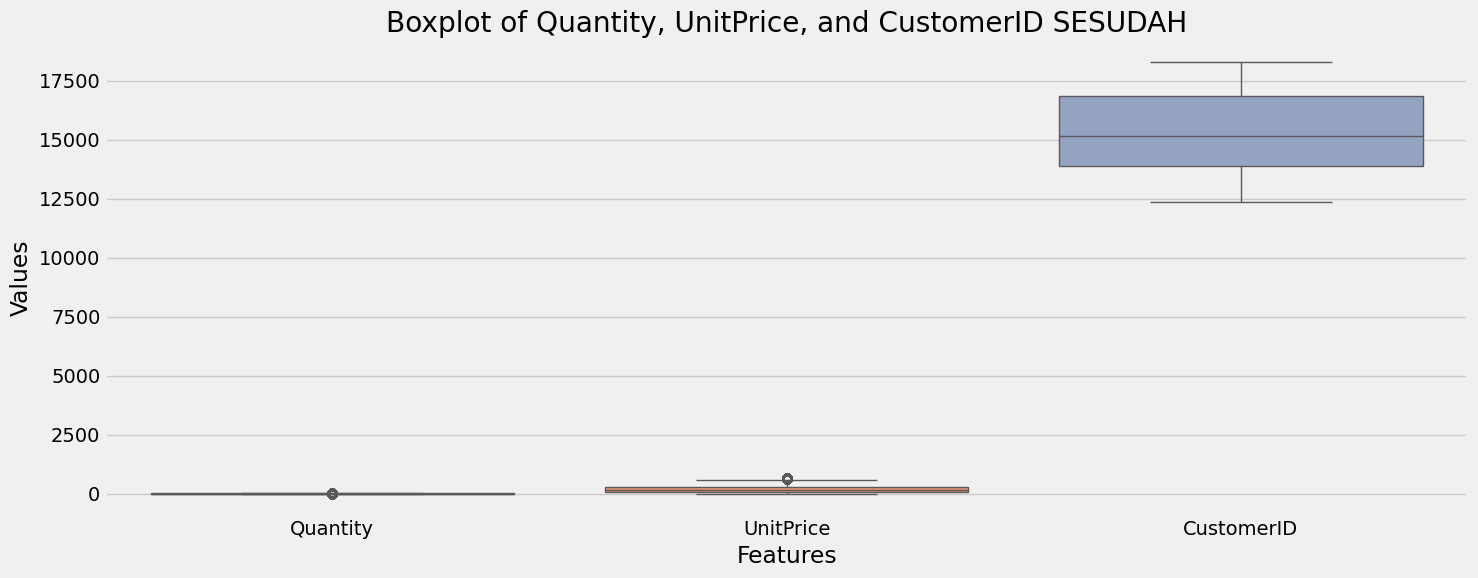

In [31]:
plt.figure(figsize=(15, 6))
sns.boxplot(data=df_cleaned[['Quantity', 'UnitPrice', 'CustomerID']], palette="Set2")
plt.title('Boxplot of Quantity, UnitPrice, and CustomerID SESUDAH')
plt.xlabel('Features')
plt.ylabel('Values')
plt.tight_layout()
plt.show()

In [32]:
# Menampilkan data setelah menangani outlier
print("Data setelah menangani outlier".center(75, "="))
print(df_cleaned.head())
print("=" * 75)

=======================Data setelah menangani outlier======================
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER       6.0   
1    536365     71053                  WHITE METAL LANTERN       6.0   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER       8.0   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE       6.0   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.       6.0   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-01-12 08:26:00      255.0     17850.0  United Kingdom  
1 2010-01-12 08:26:00      339.0     17850.0  United Kingdom  
2 2010-01-12 08:26:00      275.0     17850.0  United Kingdom  
3 2010-01-12 08:26:00      339.0     17850.0  United Kingdom  
4 2010-01-12 08:26:00      339.0     17850.0  United Kingdom  


### 8. Amati bentuk visual masing-masing fitur 

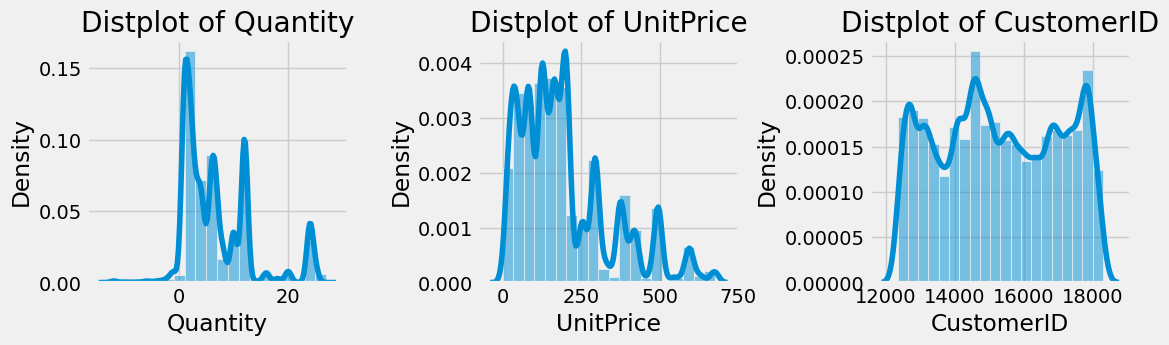

In [33]:
plt.style.use('fivethirtyeight')
plt.figure(1, figsize=(12, 3))
n = 0
for x in ['Quantity', 'UnitPrice', 'CustomerID']:
    n += 1
    plt.subplot(1, 3, n)
    plt.subplots_adjust(hspace=0.5, wspace=0.5)
    sns.histplot(
        df_cleaned[x], kde=True,
        stat="density", kde_kws=dict(cut=3), bins=20)
    plt.title('Distplot of {}'.format(x))
plt.show()

### 9. Ploting untuk mencari relasi antara 'Quantity', 'UnitPrice', dan 'CustomerID'

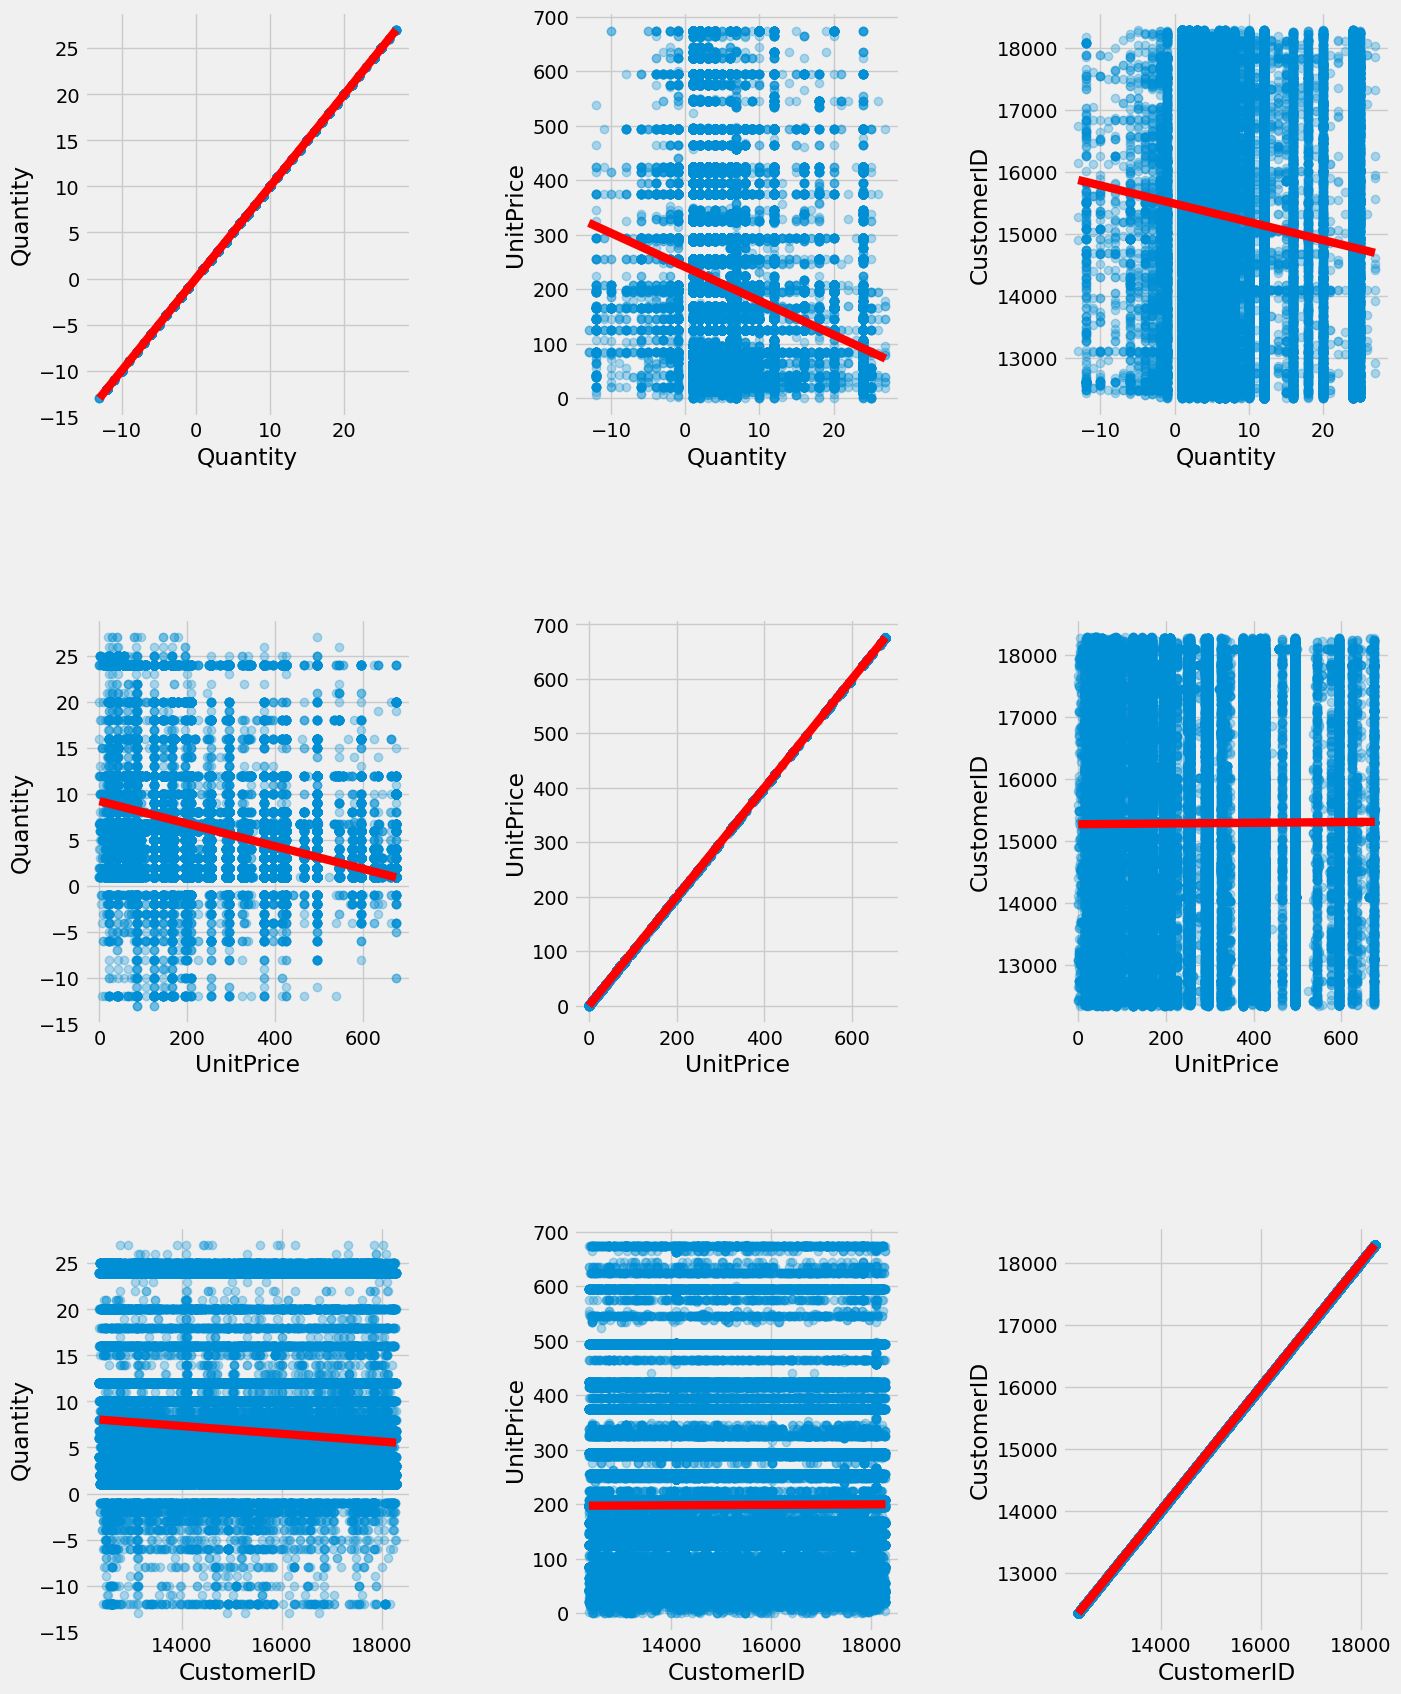

In [34]:
plt.figure(1, figsize=(15, 20))
n = 0

for x in ['Quantity', 'UnitPrice', 'CustomerID']:
    for y in ['Quantity', 'UnitPrice', 'CustomerID']:
        n += 1
        plt.subplot(3, 3, n)
        plt.subplots_adjust(hspace=0.5, wspace=0.5)
        sns.regplot(x=x, y=y, data=df_cleaned, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
        plt.xlabel(x.split()[0]+' '+x.split()[1] if len(x.split()) > 1 else x)
        plt.ylabel(y.split()[0]+' '+y.split()[1] if len(y.split()) > 1 else y)

plt.show()

### 10. Melihat sebaran quantity dan unit price pada negara

c:\Users\Dian Pratiwi\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


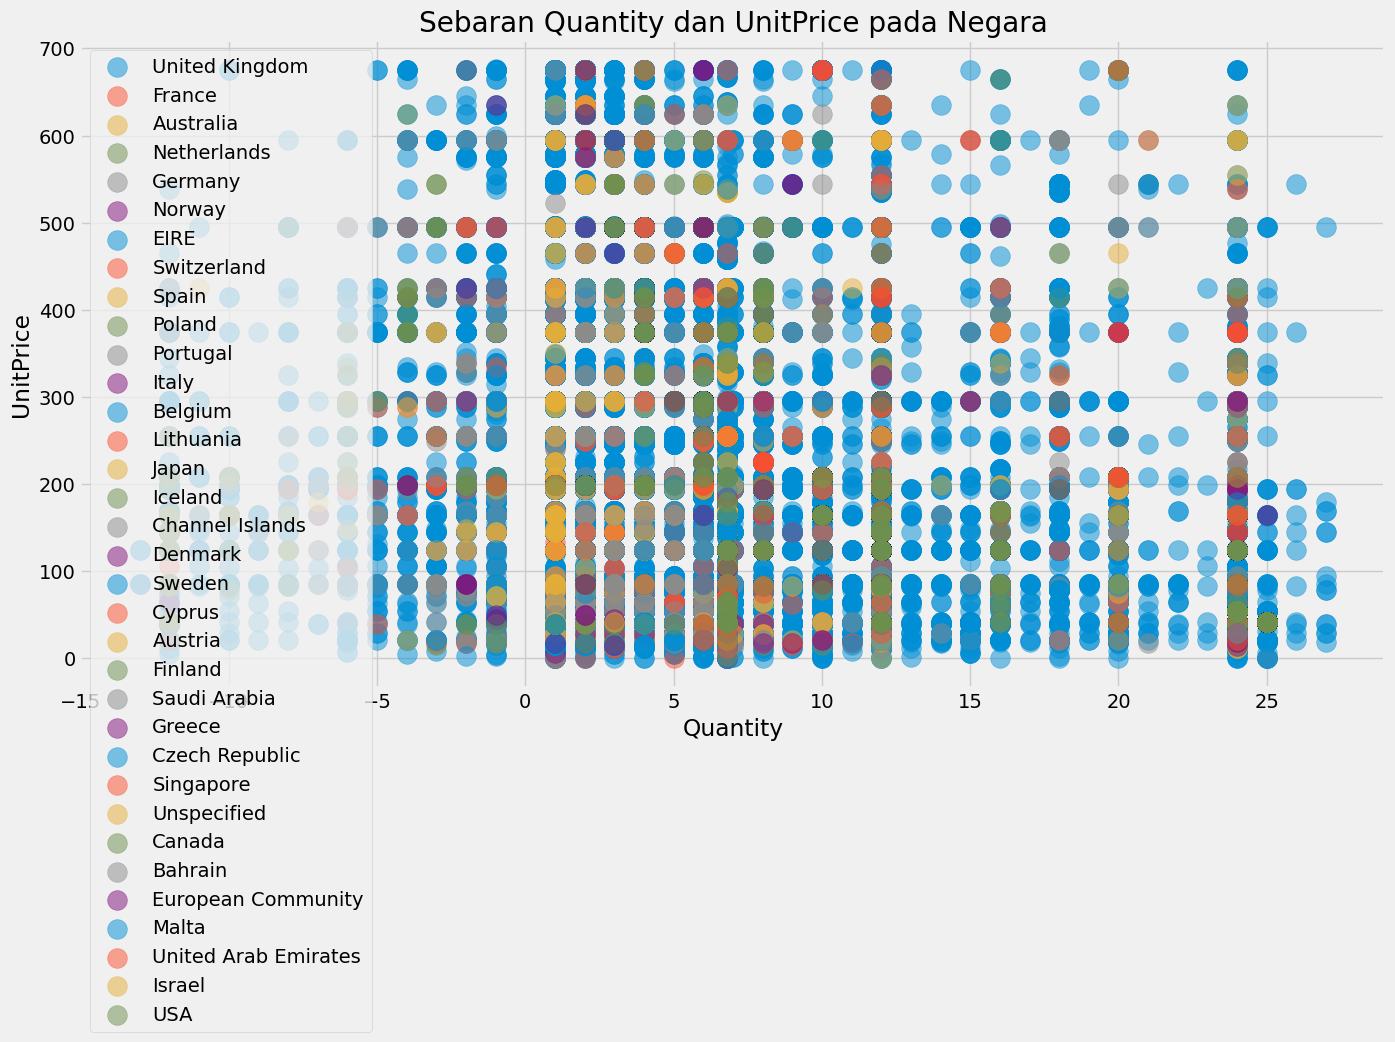

In [35]:
plt.figure(1, figsize=(15, 8))
for country in df_cleaned['Country'].unique():
    plt.scatter(x=df_cleaned[df_cleaned['Country'] == country]['Quantity'], 
                y=df_cleaned[df_cleaned['Country'] == country]['UnitPrice'],
                s=200, alpha=0.5, label=country)

plt.xlabel('Quantity')
plt.ylabel('UnitPrice')
plt.title('Sebaran Quantity dan UnitPrice pada Negara')
plt.legend()
plt.show()

### 11. Merancang K-Means untuk Quantity vs Unit Price dan Menentukan nilai k yang sesuai dengan Elbow-Method 

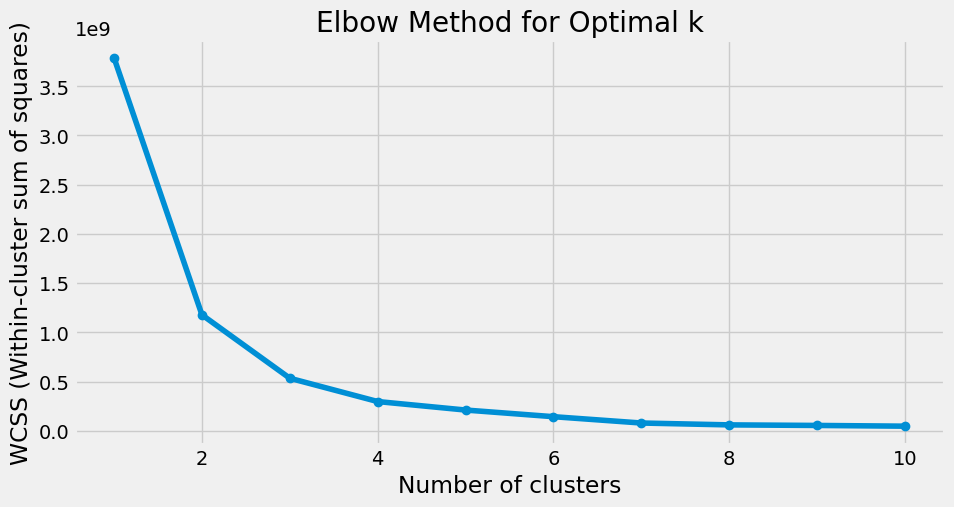

In [36]:
# Menyiapkan data untuk clustering
X = df_cleaned[['Quantity', 'UnitPrice']]

# Menentukan nilai k yang sesuai menggunakan Elbow Method
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plotting Elbow Method
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS (Within-cluster sum of squares)')
plt.show()

### 12.Membangun K-Means

In [37]:
# Menentukan jumlah cluster berdasarkan hasil Elbow Method, misalkan k=4
kmeans = KMeans(n_clusters=4, random_state=42)
df_cleaned['Cluster'] = kmeans.fit_predict(X)

### 13. Menyiapkan data untuk bentuk visual cluster

In [38]:
cluster_centers = kmeans.cluster_centers_
df_cleaned['Cluster'] = kmeans.labels_

### 14. Melihat bentuk visual cluster

c:\Users\Dian Pratiwi\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


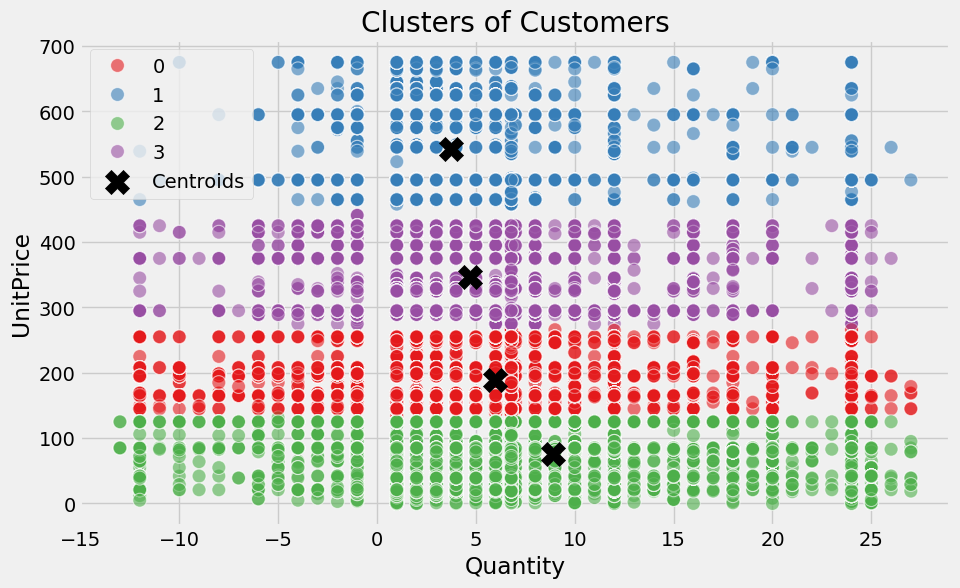

In [39]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Quantity', y='UnitPrice', hue='Cluster', data=df_cleaned, palette='Set1', s=100, alpha=0.6)
plt.scatter(cluster_centers[:, 0], cluster_centers[:, 1], s=300, c='black', marker='X', label='Centroids')
plt.title('Clusters of Customers')
plt.xlabel('Quantity')
plt.ylabel('UnitPrice')
plt.legend()
plt.show()

### 15. Melihat silhouette score

In [40]:
score = silhouette_score(X, df_cleaned['Cluster'])
print(f'Silhouette Score: {score:.3f}')

Silhouette Score: 0.584
